<a href="https://colab.research.google.com/github/prajitk2006/LAB_PROJECTS/blob/main/LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First five observations:


,Feature_1,Feature_2,Target
0,4.370861,46.330635,14.200388
1,9.556429,19.582476,107.793169
2,7.587945,15.795795,86.823084
3,6.387926,29.578110,52.964654
4,2.404168,49.426018,-18.193865



Descriptive Statistics:


,Feature_1,Feature_2,Target
count,150.000000,150.000000,150.000000
mean,5.255984,30.700883,38.996611
std,2.668777,11.656472,37.866339
min,1.049699,10.202463,-19.996596
25%,2.933032,19.899106,7.473463
50%,5.033001,32.240041,28.779551
75%,7.746957,40.313503,70.787573
max,9.881982,49.602154,124.639633



Missing values:
Feature_1    0
Feature_2    0
Target       0
dtype: int64

Pearson Correlation (Feature_1 vs Target): 0.9708 (p-value: 0.0000)


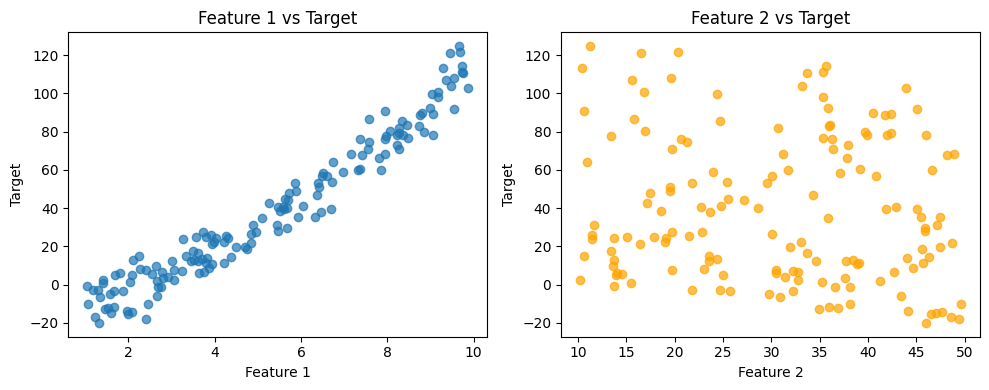


Linear Regression
------------------------------
R²   : 0.9666
RMSE : 6.9897
MAE  : 5.3643

Polynomial Regression
------------------------------
R²   : 0.9827
RMSE : 5.0338
MAE  : 3.7950

Ridge Regression
------------------------------
R²   : 0.9673
RMSE : 6.9136
MAE  : 5.2884

Lasso Regression
------------------------------
R²   : 0.9669
RMSE : 6.9568
MAE  : 5.3424

Model Comparison:


,Model,R2,RMSE,MAE
0,Linear Regression,0.966608,6.989703,5.364319
1,Polynomial Regression,0.982682,5.033775,3.795046
2,Ridge Regression,0.967332,6.913590,5.288370
3,Lasso Regression,0.966922,6.956771,5.342428



5-Fold Cross Validation:
Linear Regression Mean CV R² = 0.9674
Polynomial Regression Mean CV R² = 0.9829
Ridge Regression Mean CV R² = 0.9674
Lasso Regression Mean CV R² = 0.9674

MOST SUITABLE REGRESSION MODEL
Polynomial Regression
Mean Cross-Validated R² = 0.9829


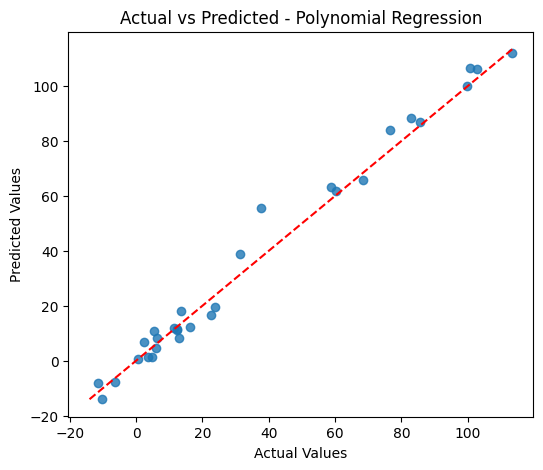

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

np.random.seed(42)
n_samples = 150

x1 = np.random.uniform(1, 10, n_samples)
x2 = np.random.uniform(10, 50, n_samples)
y = 5 * x1 + 0.8 * (x1 ** 2) - 0.5 * x2 + np.random.normal(0, 5, n_samples)

data = pd.DataFrame({"Feature_1": x1, "Feature_2": x2, "Target": y})

print("First five observations:")
display(data.head())

print("\nDescriptive Statistics:")
display(data.describe())

print("\nMissing values:")
print(data.isnull().sum())

correlation, p_value = pearsonr(data["Feature_1"], data["Target"])
print(f"\nPearson Correlation (Feature_1 vs Target): {correlation:.4f} (p-value: {p_value:.4f})")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(data["Feature_1"], data["Target"], alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Target")
plt.title("Feature 1 vs Target")

plt.subplot(1, 2, 2)
plt.scatter(data["Feature_2"], data["Target"], alpha=0.7, color='orange')
plt.xlabel("Feature 2")
plt.ylabel("Target")
plt.title("Feature 2 vs Target")
plt.tight_layout()
plt.show()

X_data = data[["Feature_1", "Feature_2"]]
Y_data = data["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, Y_data,
    test_size=0.20,
    random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

lasso_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n{name}\n" + "-" * 30)
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    return r2, rmse, mae

results = []
models_predictions = [
    ("Linear Regression", y_pred_linear),
    ("Polynomial Regression", y_pred_poly),
    ("Ridge Regression", y_pred_ridge),
    ("Lasso Regression", y_pred_lasso)
]

for name, prediction in models_predictions:
    r2, rmse, mae = evaluate_model(name, y_test, prediction)
    results.append([name, r2, rmse, mae])

results_df = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])
print("\nModel Comparison:")
display(results_df)

print("\n5-Fold Cross Validation:")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": make_pipeline(
        PolynomialFeatures(degree=2),
        LinearRegression()
    ),
    "Ridge Regression": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    "Lasso Regression": make_pipeline(
        StandardScaler(),
        Lasso(alpha=0.1)
    )
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_data, Y_data, cv=kf, scoring="r2")
    cv_results[name] = scores.mean()
    print(f"{name} Mean CV R² = {scores.mean():.4f}")

best_model = max(cv_results, key=cv_results.get)
print("\n================================")
print("MOST SUITABLE REGRESSION MODEL")
print("================================")
print(best_model)
print(f"Mean Cross-Validated R² = {cv_results[best_model]:.4f}")

best_predictions = dict(models_predictions)[best_model]
plt.figure(figsize=(6, 5))
plt.scatter(y_test, best_predictions, alpha=0.8)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model}")

minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())
plt.plot([minimum, maximum], [minimum, maximum], color='red', linestyle="--")
plt.show()